In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import seaborn as sns

from pathlib import Path
from MITRotor import IEA22MW

In [2]:
rotor = IEA22MW()

nElements = 37
nSections = 224

In [3]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [4]:
# casenames = [r'new_c_ceoff/U06', r'new_c_ceoff/U07', r'new_c_ceoff/U08', r'new_c_ceoff/U09', r'new_c_ceoff/U10']
casenames = [r'U06', r'U07', r'U08', r'U09', r'U10']

# casenames = [r'U09']

wrfles_bem = []
# wrfles_wind = []
for count, name in enumerate(casenames):
    wrfles_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/shapiro_testing/22MW/'+casenames[count]+'_lite.npz')))


In [5]:
file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/shapiro_testing/22MW/*/input_sounding")

data = extract_columns(file_list)

t = np.linspace(0,2*np.pi,nSections)
r = np.linspace(0,1,nElements)

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles_bem[0]['diameter']/2 + 378

In [15]:
data

{'U06': array([[  0.,   6.,   0.],
        [  1.,   6.,   0.],
        [  2.,   6.,   0.],
        ...,
        [829.,   6.,   0.],
        [830.,   6.,   0.],
        [831.,   6.,   0.]], shape=(832, 3)),
 'U07': array([[  0.,   7.,   0.],
        [  1.,   7.,   0.],
        [  2.,   7.,   0.],
        ...,
        [829.,   7.,   0.],
        [830.,   7.,   0.],
        [831.,   7.,   0.]], shape=(832, 3)),
 'U08': array([[  0.,   8.,   0.],
        [  1.,   8.,   0.],
        [  2.,   8.,   0.],
        ...,
        [829.,   8.,   0.],
        [830.,   8.,   0.],
        [831.,   8.,   0.]], shape=(832, 3)),
 'U09': array([[  0.,   9.,   0.],
        [  1.,   9.,   0.],
        [  2.,   9.,   0.],
        ...,
        [829.,   9.,   0.],
        [830.,   9.,   0.],
        [831.,   9.,   0.]], shape=(832, 3)),
 'U10': array([[  0.,  10.,   0.],
        [  1.,  10.,   0.],
        [  2.,  10.,   0.],
        ...,
        [829.,  10.,   0.],
        [830.,  10.,   0.],
        [831.,  

In [6]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

/tmp/ipykernel_1708851/3807191408.py:77: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=110, edgecolor='none',color=colors[count],alpha=0.5,label = leg_strs[count], zorder = count + 2)


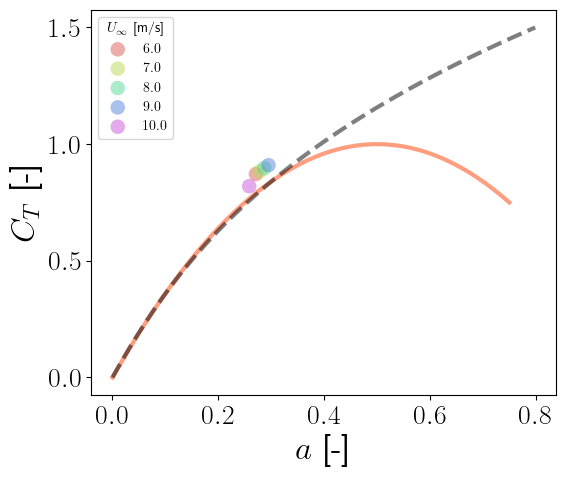

In [7]:
xs = [0,1,1,1,2,3,3,3,3,3,4,5,5,5,6]
ys = [2,1,2,3,2,0,1,2,3,4,2,1,2,3,2]

leg_strs = ['$6.0$','$7.0$','$8.0$', '$9.0$', '$10.0$']
# leg_strs = ['$7.0$','$8.0$', '$9.0$', '$10.0$']


ind_rotor = np.zeros_like(xs, dtype=float)
ct_rotor  = np.zeros_like(xs, dtype=float)

ind_loc = np.zeros((nElements, nSections, len(xs)))
ct_loc  = np.zeros((nElements, nSections, len(xs)))

colors = sns.color_palette("hls", 5)

fig, ax = plt.subplots(figsize=(6, 5))

for count,case in enumerate(casenames):
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Get radial points
    # a = ((wrfles_bem[count]['rOverR'] * rotor.R) - rotor.hub_radius)/rotor.R
    # r = (rotor.hub_radius + a * (rotor.R - rotor.hub_radius)) / rotor.R

    # r = wrfles_bem[count]['rOverR'] * rotor.R
    r = [4.28E-02,6.90E-02,9.52E-02,0.1214377,0.1476635,0.1738892,0.200115,0.2263407,0.2525665,0.2787922,0.3050179,0.3312436,0.3574694,0.3836951,0.4099208,0.4361465,0.4623722,0.4885979,0.5148236,0.5410494,0.567275,0.5935008,0.6197265,0.6459522,0.672178,0.6984037,0.7246294,0.7508551,0.7770808,0.8033066,0.8295323,0.855758,0.8819837,0.9082094,0.9344352,0.9606609,0.9868866]

    # Compute induction
    ind = 1 - np.mean(wrfles_bem[count]['shapiroM'][0] * wrfles_bem[count]['u'],axis=0) / u_inf.T
    # ind = 1 - np.mean(wrfles_bem[count]['u'],axis=0) / u_inf.T


    phi = np.deg2rad(np.mean(wrfles_bem[count]['phi'], axis=0))
    Cl = np.mean(wrfles_bem[count]['cl'], axis=0)
    Cd = np.mean(wrfles_bem[count]['cd'], axis=0)

    r_vec = r

    r =  (np.ones_like(Cd.T) * r).T * wrfles_bem[count]['diameter']/2

    # Solidity
    # sigma = rotor.solidity_func(r)

    chord = [5.801985,6.045815,6.469209,6.811252,7.041192,7.172678,7.216895,7.191829,7.111419,6.984312,6.816478,6.619332,6.399489,6.161052,5.909961,5.651033,5.387653,5.123365,4.861062,4.603144,4.352759,4.110734,3.878299,3.658778,3.451089,3.255579,3.074064,2.904848,2.746499,2.59832,2.457528,2.320188,2.181298,2.034195,1.867106,1.617766,1.025595]

    chord =  (np.ones_like(Cd.T) * chord).T

    sigma = (3 * chord) / (2 * np.pi * r)

    # Relative velocity
    W = np.mean(wrfles_bem[count]['vrel'], axis=0) / ((u_inf**2 + v_inf**2)**(1/2)).T

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    # ct = sigma * W**2 * Cax * wrfles_bem[count]['shapiroM'][0]**2
    ct = sigma * W**2 * Cax


    ind_loc[:,:,count] = ind
    ct_loc[:,:,count]  = ct

    ct_annular  = 1/(2 * np.pi) * np.trapezoid(ct, np.linspace(0, 2*np.pi, nSections), axis=-1)
    ind_annular = 1/(2 * np.pi) * np.trapezoid(ind, np.linspace(0, 2*np.pi, nSections), axis=-1)

    ct_rotor[count]  = 2 * np.trapezoid(ct_annular * r_vec, r_vec)
    ind_rotor[count] = 2 * np.trapezoid(ind_annular * r_vec, r_vec)

    # ct_rotor[count]  = 2 * np.trapezoid(ct_annular * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])
    # ind_rotor[count] = 2 * np.trapezoid(ind_annular * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])

    ax.scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=110, edgecolor='none',color=colors[count],alpha=0.5,label = leg_strs[count], zorder = count + 2)

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,alpha = 0.5, zorder = 1)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,alpha=0.5,zorder=2)

ax.set_xlabel('$a$ [-]', fontsize=fontsize)
ax.set_ylabel('$C_T$ [-]', fontsize=fontsize)

plt.legend(title='$U_{\infty}$ [m/s]')

# ax[0,0].axis('off')
# ax[0,1].axis('off')
# ax[0,3].axis('off')


# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)
plt.show()

In [8]:
r

array([[  6.0632192 ,   6.0632192 ,   6.0632192 , ...,   6.0632192 ,
          6.0632192 ,   6.0632192 ],
       [  9.774816  ,   9.774816  ,   9.774816  , ...,   9.774816  ,
          9.774816  ,   9.774816  ],
       [ 13.4864128 ,  13.4864128 ,  13.4864128 , ...,  13.4864128 ,
         13.4864128 ,  13.4864128 ],
       ...,
       [132.37582817, 132.37582817, 132.37582817, ..., 132.37582817,
        132.37582817, 132.37582817],
       [136.09106574, 136.09106574, 136.09106574, ..., 136.09106574,
        136.09106574, 136.09106574],
       [139.8063033 , 139.8063033 , 139.8063033 , ..., 139.8063033 ,
        139.8063033 , 139.8063033 ]], shape=(37, 224))

In [12]:
ind_rotor

array([0.28087292, 0.26117907, 0.26043712, 0.25994619, 0.25952751,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [13]:
ct_rotor

array([0.86290754, 0.81053641, 0.80413064, 0.79858556, 0.79373355,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [16]:
case

'U10'

In [27]:
wrfles_bem[count]['shapiroM'][0]**2

array([0.97591877], dtype=float32)

In [18]:
wrfles_bem[count]['u']

array([[[6.060541 , 6.0631466, 6.065648 , ..., 6.052157 , 6.0550385,
         6.057836 ],
        [5.9844985, 5.9864507, 5.9885454, ..., 5.979339 , 5.9809594,
         5.982674 ],
        [5.4406223, 5.438729 , 5.438992 , ..., 5.458459 , 5.4505706,
         5.4445963],
        ...,
        [4.0875   , 4.091281 , 3.964323 , ..., 3.979472 , 3.9622376,
         4.0899754],
        [4.4130154, 4.4253416, 4.4540253, ..., 4.482146 , 4.450758 ,
         4.4235926],
        [5.0617924, 5.061225 , 5.0576496, ..., 5.046775 , 5.0541296,
         5.0593977]],

       [[6.0602846, 6.062889 , 6.065389 , ..., 6.0519037, 6.054783 ,
         6.05758  ],
        [5.984113 , 5.9860635, 5.9881573, ..., 5.978961 , 5.9805775,
         5.982291 ],
        [5.4405007, 5.4385977, 5.4388533, ..., 5.458362 , 5.450465 ,
         5.444484 ],
        ...,
        [4.087411 , 4.091256 , 3.9644277, ..., 3.9794831, 3.962278 ,
         4.0898952],
        [4.41282  , 4.425227 , 4.45391  , ..., 4.4819593, 4.45065  ,
   

In [22]:
Cax

array([[0.55311567, 0.550087  , 0.5503691 , ..., 0.5528241 , 0.5529115 ,
        0.5530088 ],
       [0.47741258, 0.47411898, 0.4745157 , ..., 0.47729778, 0.47731954,
        0.4773571 ],
       [1.2861124 , 1.2866423 , 1.2866321 , ..., 1.2859057 , 1.2859784 ,
        1.2860479 ],
       ...,
       [1.3096434 , 1.2974792 , 1.298606  , ..., 1.2996897 , 1.2984245 ,
        1.2973996 ],
       [1.191884  , 1.1927899 , 1.1948885 , ..., 1.1969832 , 1.194574  ,
        1.192642  ],
       [1.1693043 , 1.1692417 , 1.1688918 , ..., 1.1678233 , 1.1685575 ,
        1.1690876 ]], shape=(26, 158), dtype=float32)

In [6]:
wrfles_bem[1]['shapiroM']

array([[0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274]], dtype=float32)